<a href="https://colab.research.google.com/github/EngenhariaSoftwarePUCRS/Inteligencia_Artificial/blob/develop/Trabalho01/Trabalho01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
integrantes = ["Augusto Baldino", "Felipe Freitas", "Isabela Kuser", "Luiza Heller", "Maria Eduarda Maia", "Paola Lopes"]
useful_links = [
    "https://pandas.pydata.org/pandas-docs/version/1.0/user_guide/style.html",
    "https://www.geeksforgeeks.org/how-to-replace-values-in-column-based-on-condition-in-pandas/",
    "https://www.geeksforgeeks.org/how-to-add-header-row-to-a-pandas-dataframe/",
    "https://discuss.streamlit.io/t/is-it-possible-to-center-data-on-cell-like-excel/32045/7",
]

In [192]:
# This block contains all required imports
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from seaborn.palettes import mpl_palette as colors
from sklearn import (
    cluster,
    metrics,
    model_selection,
    neighbors,
    neural_network,
    tree,
)
from typing import Annotated, Literal

In [209]:
# This block contains the dataset initial import and column names
targetClass = "Outcome"
columnNames = [
    "Top-Left", "Top-Middle", "Top-Right",
    "Middle-Left", "Middle-Middle", "Middle-Right",
    "Bottom-Left", "Bottom-Middle", "Bottom-Right",
    targetClass,
]
dataset = pd.read_csv(
    "tic-tac-toe-minimum.data",
    names=columnNames,
)

In [93]:
# This block contains possible game output values
X_GANHOU = "X Ganhou"
O_GANHOU = "O Ganhou"
VELHA = "Deu Velha"
TEM_JOGO = "Tem Jogo"
gameOutput = Literal["X Ganhou", "O Ganhou", "Deu Velha", "Tem Jogo"]

In [94]:
# This block handles cell logic and field values
# It is used for guaranteeing consistency when comparing diferent cells
cellStrType = Literal['x', 'b', 'o']
cellNumType = Literal[1, 0, -1]
cellEntry = cellStrType | cellNumType

class Cell:
    raw: cellStrType
    value: cellNumType
    def __init__(self, raw: cellStrType, value: cellNumType):
        self.raw = raw
        self.value = value

    def __str__(self) -> str:
        if (self.raw == 'b'):
            return ' '
        return self.raw

    def __repr__(self) -> str:
        return f"<Cell {self.raw} | {self.value}>"

    def get_entries(self) -> list[cellEntry]:
        return [self.raw, self.value]

CELL_X = Cell('x', 1)
CELL_O = Cell('o', -1)
CELL_B = Cell('b', 0)

In [95]:
# This block is a function that converts a cell entry to a valid cell
# It is used to guarantee consistency when handling the data values
def to_cell(cell: cellEntry) -> Cell:
    # Python...
    if isinstance(cell, Cell):
        return cell

    for cell_model in [CELL_X, CELL_B, CELL_O]:
        if cell in cell_model.get_entries():
            return cell_model

    raise Exception(f"Invalid entry '{cell}', please check your dataset")

In [96]:
# This block is a function that prints the board in a human-readable format
# It is used mostly for debugging
def print_board(board: list[cellEntry]):
    for i in range(0, 9, 3):
        row_raw = board[i:i+3]
        row_cell = [to_cell(cell) for cell in row_raw]
        row_string = [str(cell) for cell in row_cell]
        row_pretty = " | ".join(row_string)
        print(row_pretty)

In [97]:
# This block is a function that checks wether a player has won the game
# It is used on the initial dataset transformation, to convert the target column appropriately
def has_won(player: Cell, board: list[Cell]) -> bool:
    if len(board) != 9:
        raise ValueError("Board cannot have any different number of rows x columns than 9")

    for i in range(0, 9, 3):
        line = board[i:i+3]
        # print("Line: ", line)
        if all(cell == player for cell in line):
            return True

    for i in range(0, 3):
        column = [board[i], board[i+3], board[i+6]]
        # print("Column: ", column)
        if all(cell == player for cell in column):
            return True

    if board[4] != player:
        return False

    diagonal1 = [board[0], board[8]]
    # print("D1: ", diagonal1)
    if all(cell == player for cell in diagonal1):
        return True

    diagonal2 = [board[2], board[6]]
    # print("D2: ", diagonal2)
    if all(cell == player for cell in diagonal2):
        return True

    return False

In [98]:
# Simply check wether dataset appears to be correct on its initial state
dataset.head(3)

,Top-Left,Top-Middle,Top-Right,Middle-Left,Middle-Middle,Middle-Right,Bottom-Left,Bottom-Middle,Bottom-Right,Outcome
0,x,x,x,x,o,o,x,o,o,positive
1,x,x,x,o,b,o,o,x,b,positive
2,x,x,o,x,o,x,x,o,o,positive


In [210]:
# This block handles the majority of the dataset's transformation
# It should convert all cells into their numeric counterparts
# It should also adjust the output column to the proper value
for index, row in dataset.iterrows():
    board: list[Cell] = []
    for i, cell_str in enumerate(row.array.tolist()[:-1]):
        columnName = columnNames[i]
        cell = to_cell(cell_str)
        dataset.at[index, columnName] = cell.value
        board.append(cell)

    if (row[targetClass] == 'positive') or has_won(CELL_X, board):
        targetValue = X_GANHOU
    elif has_won(CELL_O, board):
        targetValue = O_GANHOU
    elif CELL_B in board:
        targetValue = TEM_JOGO
    else:
        targetValue = VELHA

    dataset.at[index, targetClass] = targetValue

In [169]:
# Properly check wether dataset was fully transformed to desired outputs (numerically)
x_ganhou_count = dataset[targetClass].eq(X_GANHOU).sum()
o_ganhou_count = dataset[targetClass].eq(O_GANHOU).sum()
deu_velha_count = dataset[targetClass].eq(VELHA).sum()
tem_jogo_count = dataset[targetClass].eq(TEM_JOGO).sum()

outcomes: dict[str, int] = {
    X_GANHOU: x_ganhou_count,
    O_GANHOU: o_ganhou_count,
    VELHA: deu_velha_count,
    TEM_JOGO: tem_jogo_count,
}

# Calculate the length of each header for formatting
outcome_length = max(len(outcome) for outcome in outcomes.keys())
count_length = max(len(str(count)) for count in outcomes.values())
count_length = max(count_length, len(" Count "))
percentage_length = len("Percentage")

print(f"| {'Outcome':<{outcome_length}} | {'Count':<{count_length}} | {'Percentage':<{percentage_length}} |")
print(f"|{'-' * (outcome_length + 2)}|{'-' * (count_length + 2)}|{'-' * (percentage_length + 2)}|")
for outcome, count in outcomes.items():
    percentage = (count / len(dataset)) * 100
    print(f"| {outcome:<{outcome_length}} | {count:<{count_length}} | {percentage:>{percentage_length - 1}.4f}% |")

| Outcome   | Count   | Percentage |
|-----------|---------|------------|
| X Ganhou  | 16      |   25.0000% |
| O Ganhou  | 16      |   25.0000% |
| Deu Velha | 16      |   25.0000% |
| Tem Jogo  | 16      |   25.0000% |


In [211]:
# This block splits the dataset equally for testing across different models

# Define the features (X) and the target variable (y)
X = dataset.drop(columns=[targetClass])
y = dataset[targetClass]

# Define the split ratios
split_ratios = {'train': 0.75, 'validation': 0.125, 'test': 0.125}
# Assure that it adds to 1
if sum(split_ratios.values()) != 1.0:
    raise Exception("Ratios must add up to 1.0")
validation_plus_test_ratio = split_ratios['validation'] + split_ratios['test']
test_to_validation_ratio = split_ratios['test'] / validation_plus_test_ratio

# Split the data into training, validation, and test sets
X_train, X_temp, y_train, y_temp = model_selection.train_test_split(X, y, train_size=split_ratios['train'], stratify=y, random_state=42)
X_validation, X_test, y_validation, y_test = model_selection.train_test_split(X_temp, y_temp, test_size=test_to_validation_ratio, stratify=y_temp, random_state=42)

# Print the shapes of the resulting sets to verify the split
# Print the distribution of outcomes in each set
print("Training set shape/distribution:", X_train.shape)
print(y_train.value_counts(normalize=True))

print("\nValidation set shape/distribution:", X_validation.shape)
print(y_validation.value_counts(normalize=True))

print("\nTest set shape/distribution:", X_test.shape)
print(y_test.value_counts(normalize=True))

Training set shape/distribution: (48, 9)
Outcome
X Ganhou     0.25
Deu Velha    0.25
Tem Jogo     0.25
O Ganhou     0.25
Name: proportion, dtype: float64

Validation set shape/distribution: (8, 9)
Outcome
X Ganhou     0.25
Tem Jogo     0.25
Deu Velha    0.25
O Ganhou     0.25
Name: proportion, dtype: float64

Test set shape/distribution: (8, 9)
Outcome
Tem Jogo     0.25
O Ganhou     0.25
Deu Velha    0.25
X Ganhou     0.25
Name: proportion, dtype: float64


In [212]:
# This block uses the validation set to check wether the dataset is correct
for i in range(len(X_validation)):
    print("Linha", i, "Tabuleiro:")
    print_board(X_validation.iloc[i].values)
    print("Outcome: ", y_validation.iloc[i], end="\n\n")

Linha 0 Tabuleiro:
x |   |  
x | o | o
x |   |  
Outcome:  X Ganhou

Linha 1 Tabuleiro:
  |   |  
  |   | o
x | o | x
Outcome:  Tem Jogo

Linha 2 Tabuleiro:
o | x | o
x | x | o
x | o | x
Outcome:  Deu Velha

Linha 3 Tabuleiro:
o | x | x
x | o | o
x | o | x
Outcome:  Deu Velha

Linha 4 Tabuleiro:
x |   | x
x | o | x
o | o | o
Outcome:  O Ganhou

Linha 5 Tabuleiro:
o | o | o
x | x |  
x | o | x
Outcome:  O Ganhou

Linha 6 Tabuleiro:
  |   |  
  |   | x
o | o | x
Outcome:  Tem Jogo

Linha 7 Tabuleiro:
x | x | x
o |   | o
o | x |  
Outcome:  X Ganhou



<center><h2>kNN Section</h2></center>

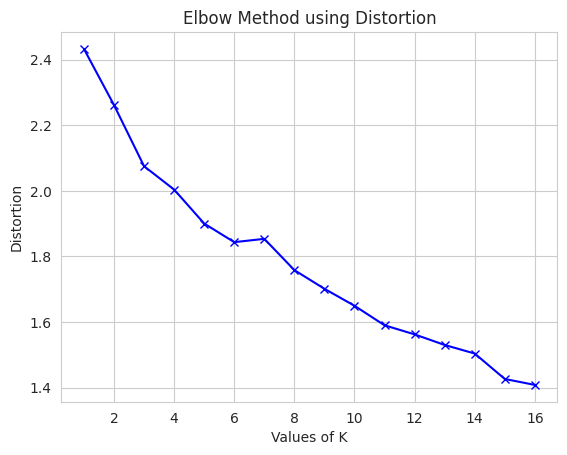

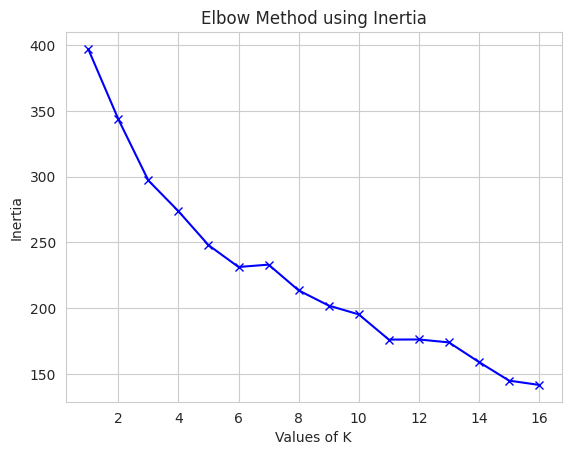

In [103]:
# Baseado no exemplo 1 de kNN; semana 4

X = dataset.drop(columns=[targetClass]).values
X = np.array(X, dtype=np.float64)

# Distorção: Calcula a distância dos pontos de cada cluster até seu centróide
distortions = []
# Inércia: Distância dos dados até o centróide mais próximos
inertias = []

# Testando valores de 1 a 16 para o número de clusters
K = range(1, 16 + 1)

for k in K:
    # Executando o K-Means para cada valor de k
    kmeanModel = cluster.KMeans(n_clusters=k, n_init='auto')
    kmeanModel.fit(X)

    # Calcula a distância de cada ponto de X ao centróide
    distancias = cdist(X, kmeanModel.cluster_centers_, 'euclidean')

    soma = 0
    for item in distancias:
        soma += min(item)
    coesao = soma / len(distancias)

    distortions.append(coesao)
    inertias.append(kmeanModel.inertia_)


# Plotting the distortion
plt.plot(K, distortions, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Distortion')
plt.title('Elbow Method using Distortion')
plt.grid(True)
plt.show()

print()

# Plotting the inertia
plt.plot(K, inertias, 'bx-')
plt.xlabel('Values of K')
plt.ylabel('Inertia')
plt.title('Elbow Method using Inertia')
plt.grid(True)
plt.show()

In [208]:
X = dataset.drop(columns=[targetClass]).values
x_ganhou = dataset.loc[dataset[targetClass] == X_GANHOU]
o_ganhou = dataset.loc[dataset[targetClass] == O_GANHOU]
deu_velha = dataset.loc[dataset[targetClass] == VELHA]
tem_jogo = dataset.loc[dataset[targetClass] == TEM_JOGO]
sns.set_style("whitegrid")
# sns.pairplot(dataset, hue=targetClass, height=3)
# plt.show()

wcss = []
for i in range(1, 16 + 1):
    kmeans = cluster.KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init=10, random_state = 0)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 16 + 1), wcss)
plt.title('The elbow method (Método do Cotovelo)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS') #within cluster sum of squares
plt.show()

k=6
kmeans = cluster.KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=0)
y_kmeans = kmeans.fit_predict(X)

C = kmeans.cluster_centers_
labels = kmeans.labels_
print("Centroides:\n", C)
print("Cluster de cada cada:\n", labels)

for iCluster in range(0, k):
  print("Cluster: ", iCluster)
  print("Centroide: ", C[iCluster])
  for indice in range(0, len(labels)):
    if(iCluster==labels[indice]):
      print(X[indice])

#Visualising the clusters
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'purple', label = X_GANHOU)
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'orange', label = O_GANHOU)
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = VELHA)
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'pink', label = TEM_JOGO)

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:,1], s = 100, c = 'red', label = 'Centroids')
plt.legend()

ValueError: could not convert string to float: 'x'

In [206]:
# This block defines the best k for the kNN algorithm (tests k's accuracy)
# for outcome, count in outcomes.items():
best_k = 16
best_accuracy = 0
for k in range(1, outcomes.get(VELHA, 0)):
    kNN_classifier = neighbors.KNeighborsClassifier(n_neighbors=k)
    kNN_classifier.fit(X_train, y_train)
    predictions_test = kNN_classifier.predict(X_test)
    accuracy = metrics.accuracy_score(y_test, predictions_test)
    if accuracy > best_accuracy:
        best_k = k
        best_accuracy = accuracy
    print(f"k-NN accuracy ({k}): {accuracy:.4f}")

print("Best: ", best_k, "accuracy: ", best_accuracy)

k-NN accuracy (1): 0.6250
k-NN accuracy (2): 0.6250
k-NN accuracy (3): 0.7500
k-NN accuracy (4): 0.7500
k-NN accuracy (5): 0.6250
k-NN accuracy (6): 0.5000
k-NN accuracy (7): 0.3750
k-NN accuracy (8): 0.5000
k-NN accuracy (9): 0.3750
k-NN accuracy (10): 0.2500
k-NN accuracy (11): 0.3750
k-NN accuracy (12): 0.2500
k-NN accuracy (13): 0.2500
k-NN accuracy (14): 0.2500
k-NN accuracy (15): 0.2500
Best:  3 accuracy:  0.75


In [173]:
# Actually setup kNN
kNN = neighbors.KNeighborsClassifier(n_neighbors=best_k)
kNN.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

<center><h2>MLP Section</h2></center>

In [188]:
MLP = neural_network.MLPClassifier(
    random_state=42,
    solver="adam",
    hidden_layer_sizes=(4,),
    learning_rate_init=0.1,
    max_iter=2048,
    verbose=True,
)

In [189]:
MLP.fit(X_train, y_train)
mlp_predictions = MLP.predict(X_test)

Iteration 1, loss = 1.43759559
Iteration 2, loss = 1.29051171
Iteration 3, loss = 1.21730145
Iteration 4, loss = 1.17935071
Iteration 5, loss = 1.14757655
Iteration 6, loss = 1.11147583
Iteration 7, loss = 1.08035755
Iteration 8, loss = 1.06443044
Iteration 9, loss = 1.05784817
Iteration 10, loss = 1.03772780
Iteration 11, loss = 1.00583421
Iteration 12, loss = 0.96989303
Iteration 13, loss = 0.93516420
Iteration 14, loss = 0.89944803
Iteration 15, loss = 0.86832032
Iteration 16, loss = 0.84660377
Iteration 17, loss = 0.82833919
Iteration 18, loss = 0.80837839
Iteration 19, loss = 0.78590089
Iteration 20, loss = 0.76446938
Iteration 21, loss = 0.74639432
Iteration 22, loss = 0.72820300
Iteration 23, loss = 0.70918674
Iteration 24, loss = 0.68959984
Iteration 25, loss = 0.67270598
Iteration 26, loss = 0.66084975
Iteration 27, loss = 0.64878020
Iteration 28, loss = 0.63855904
Iteration 29, loss = 0.62799335
Iteration 30, loss = 0.61570348
Iteration 31, loss = 0.60644972
Iteration 32, los

In [190]:
print("Confusion Matrix: \n", metrics.confusion_matrix(y_test, mlp_predictions))
print("Accuracy: ", metrics.accuracy_score(y_test, mlp_predictions))
print(metrics.classification_report(y_test, mlp_predictions, zero_division=0))

Confusion Matrix: 
 [[1 0 1 0]
 [1 1 0 0]
 [0 0 1 1]
 [0 0 1 1]]
Accuracy:  0.5
              precision    recall  f1-score   support

   Deu Velha       0.50      0.50      0.50         2
    O Ganhou       1.00      0.50      0.67         2
    Tem Jogo       0.33      0.50      0.40         2
    X Ganhou       0.50      0.50      0.50         2

    accuracy                           0.50         8
   macro avg       0.58      0.50      0.52         8
weighted avg       0.58      0.50      0.52         8



<center><h2>Decision Tree Section</h2></center>

In [196]:
DTree = tree.DecisionTreeClassifier(
    random_state=42,
    criterion='gini',
    max_depth=10,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=None,
)

In [197]:
DTree.fit(X_train, y_train)
dtree_predictions = DTree.predict(X_test)

In [198]:
print("Confusion Matrix:\n", metrics.confusion_matrix(y_test, dtree_predictions))
print("Accuracy: ", metrics.accuracy_score(y_test, dtree_predictions))
print(metrics.classification_report(y_test, dtree_predictions, zero_division=0))

Confusion Matrix:
 [[1 0 0 1]
 [0 1 0 1]
 [0 1 1 0]
 [0 0 0 2]]
Accuracy:  0.625
              precision    recall  f1-score   support

   Deu Velha       1.00      0.50      0.67         2
    O Ganhou       0.50      0.50      0.50         2
    Tem Jogo       1.00      0.50      0.67         2
    X Ganhou       0.50      1.00      0.67         2

    accuracy                           0.62         8
   macro avg       0.75      0.62      0.62         8
weighted avg       0.75      0.62      0.62         8



<center><h2>Results Section</h2></center>

In [201]:
def get_game_state(board: list[cellEntry], algorithm: Literal["kMeans", "MLP", "DTree"] = "kMeans") -> gameOutput:
    input_cell = [to_cell(cell) for cell in board]
    input_numeric = [cell.value for cell in input_cell]
    input = {columnNames[i]: input_numeric[i] for i in range(len(input_numeric))}
    input = pd.DataFrame([input])

    if algorithm == "kMeans":
        outcome, *_ = kNN.predict(input)
        return outcome

    if algorithm == "MLP":
        outcome, *_ = MLP.predict(input)
        return outcome

    if algorithm == "DTree":
        outcome, *_ = DTree.predict(input)
        return outcome

    raise Exception("Invalid Algorithm")

In [207]:
# This last block can be used as a "playground" to test the models
game_state: list[cellEntry] = [
    'x', 'o', 'x',
    'x', 'x', 'o',
    'o', 'o', 'x',
]

game_state_cells = [to_cell(cell) for cell in game_state]
if has_won(CELL_X, game_state_cells):
    correct_output = X_GANHOU
elif has_won(CELL_O, game_state_cells):
    correct_output = O_GANHOU
elif CELL_B in game_state_cells:
    correct_output = TEM_JOGO
else:
    correct_output = VELHA
print("Saída Correta: ", correct_output)

print("Saída kNN: ", get_game_state(game_state, "kMeans"))
print("Saída MLP: ", get_game_state(game_state, "MLP"))
print("Saída DTree: ", get_game_state(game_state, "DTree"))

Saída Correta:  X Ganhou
Saída kNN:  Tem Jogo
Saída MLP:  Tem Jogo
Saída DTree:  Deu Velha
